In [10]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("spscientist/students-performance-in-exams")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'students-performance-in-exams' dataset.
Path to dataset files: /kaggle/input/students-performance-in-exams


In [11]:
import os

os.listdir(path)

['StudentsPerformance.csv']

In [12]:
import pandas as pd
df = pd.read_csv(path + "/StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [13]:
df.shape

(1000, 8)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [15]:
df.isnull().sum()
# df.isnull().count()
# df.isnull()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [34]:
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.replace('/', '_')
df.columns = df.columns.str.lower()

In [37]:
df['total_score'] = (
    df['math_score'] +
    df['reading_score'] +
    df['writing_score']
)

df['average_score'] = df['total_score'] / 3

df['pass_math'] = df['math_score'] >= 40
df['pass'] = df['average_score'] >= 40

In [36]:
df[['math_score','reading_score','writing_score']].describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

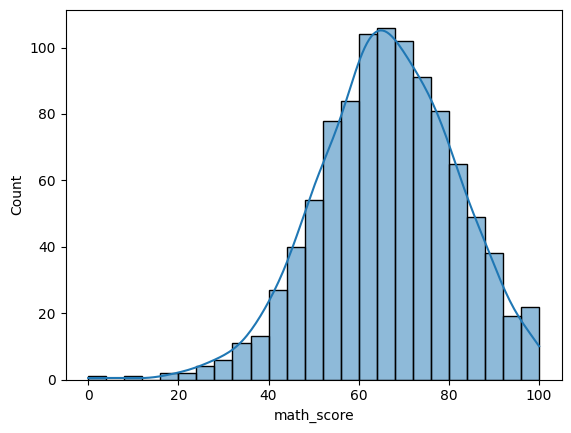

In [38]:
sns.histplot(df['math_score'], kde=True)
plt.show()

In [39]:
df['gender'].value_counts()
df['lunch'].value_counts()

,count
lunch,
standard,645
free/reduced,355


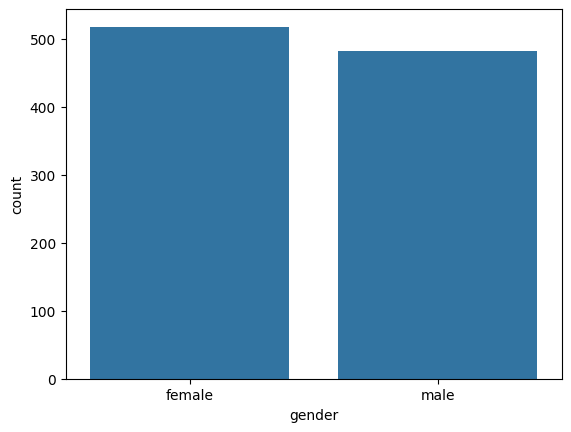

In [40]:
sns.countplot(x='gender', data=df)
plt.show()

In [41]:
df.groupby('gender')[
    ['math_score','reading_score','writing_score']
].mean()

,math_score,reading_score,writing_score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


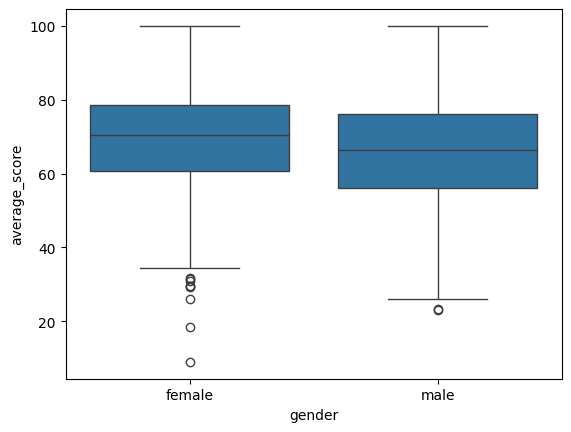

In [46]:
sns.boxplot(x='gender', y='average_score', data=df)
plt.show()

In [43]:
df.groupby('test_preparation_course')[
    ['math_score','reading_score','writing_score']
].mean()

,math_score,reading_score,writing_score
test_preparation_course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


In [47]:
df.groupby('lunch')[
    ['math_score','reading_score','writing_score']
].mean()

,math_score,reading_score,writing_score
lunch,,,
free/reduced,58.921127,64.653521,63.022535
standard,70.034109,71.654264,70.823256


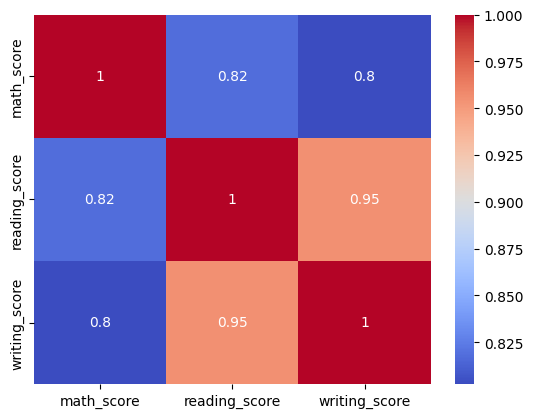

In [48]:
corr = df[['math_score',
           'reading_score',
           'writing_score']].corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')
plt.show()

In [49]:
df.groupby('parental_level_of_education')[
    'average_score'
].mean().sort_values()

,average_score
parental_level_of_education,
high school,63.096939
some high school,65.108007
some college,68.476401
associate's degree,69.569069
bachelor's degree,71.923729
master's degree,73.598870


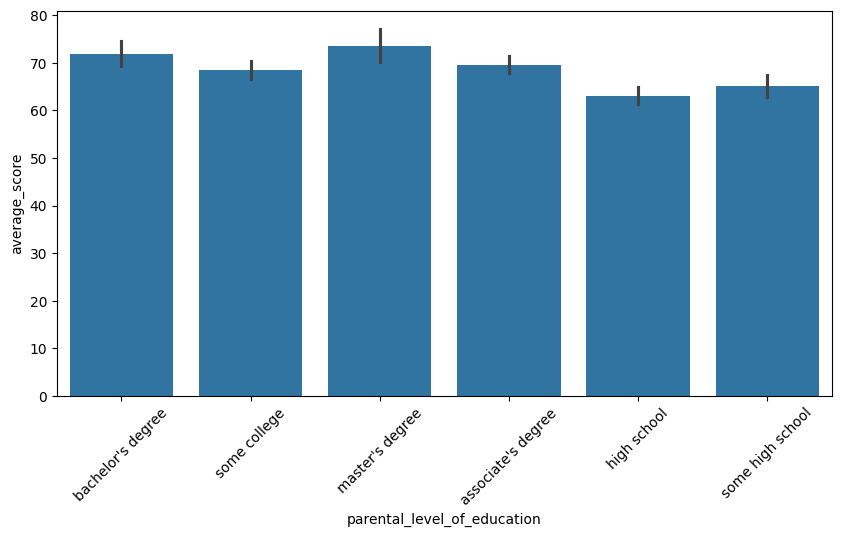

In [50]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='parental_level_of_education',
    y='average_score',
    data=df
)

plt.xticks(rotation=45)
plt.show()

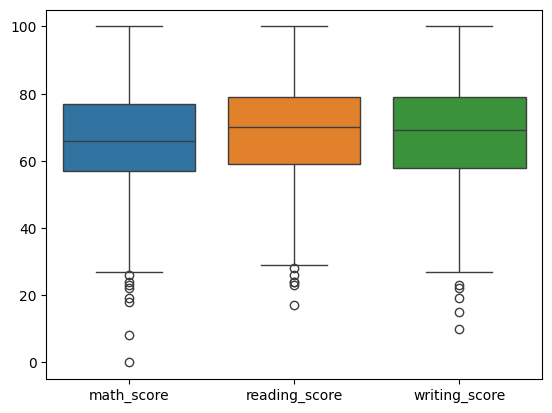

In [51]:
sns.boxplot(data=df[
    ['math_score',
     'reading_score',
     'writing_score']
])
plt.show()

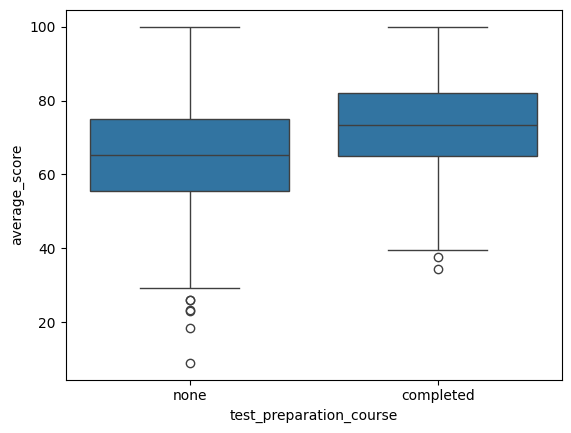

In [45]:
sns.boxplot(
    x='test_preparation_course',
    y='average_score',
    data=df
)
plt.show()

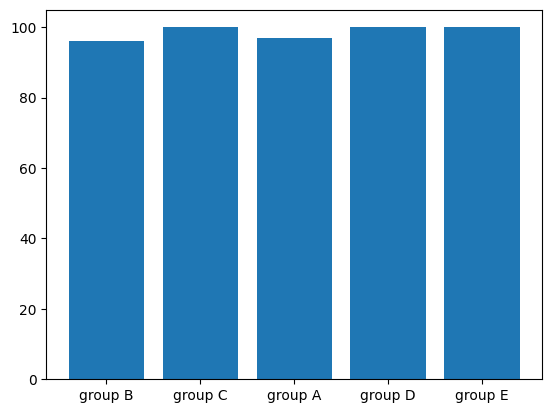

In [19]:
plt.bar(df["race/ethnicity"],df["writing_score"])
plt.show()

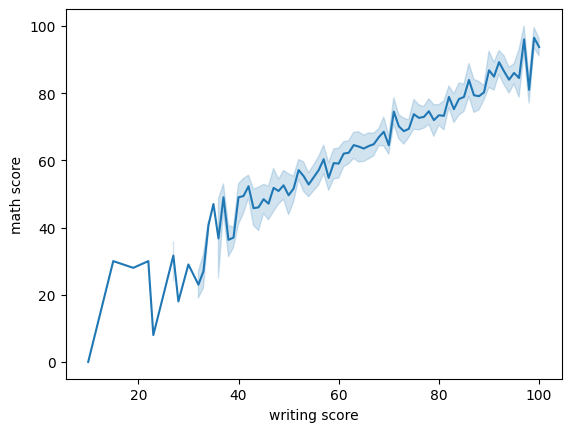

In [21]:
sns.lineplot(x="writing_score",y="math_score",data=df)
plt.show()

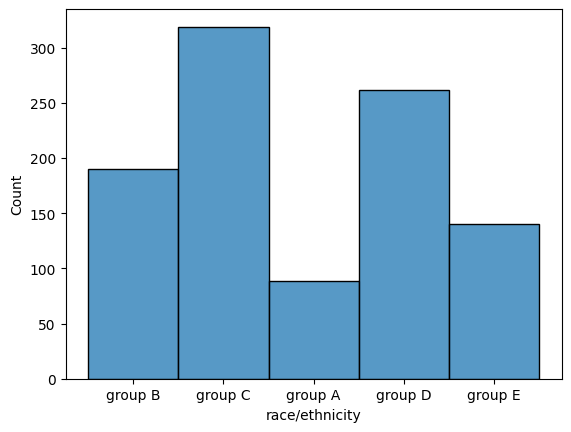

In [25]:
sns.histplot(x='race_ethnicity',data=df)
plt.show()

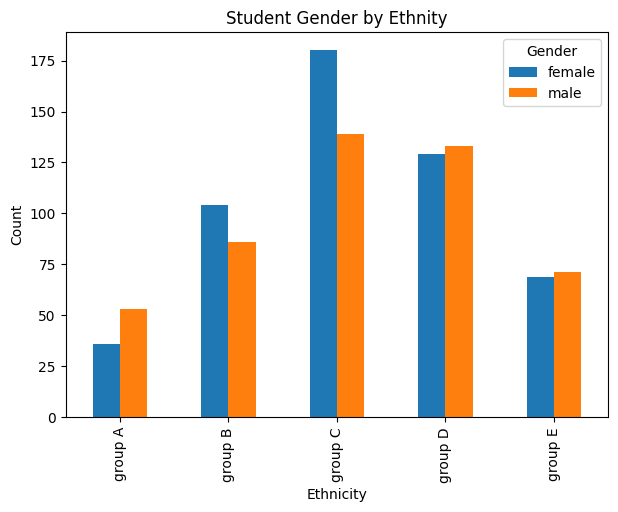

In [27]:
pd.crosstab(df['race_ethnicity'], df['gender']).plot(
    kind='bar',
    # stacked=True,
    figsize=(7,5)
)

plt.title("Student Gender by Ethnity")
plt.xlabel("Ethnicity")
plt.ylabel("Count")
plt.legend(title="Gender")
plt.show()

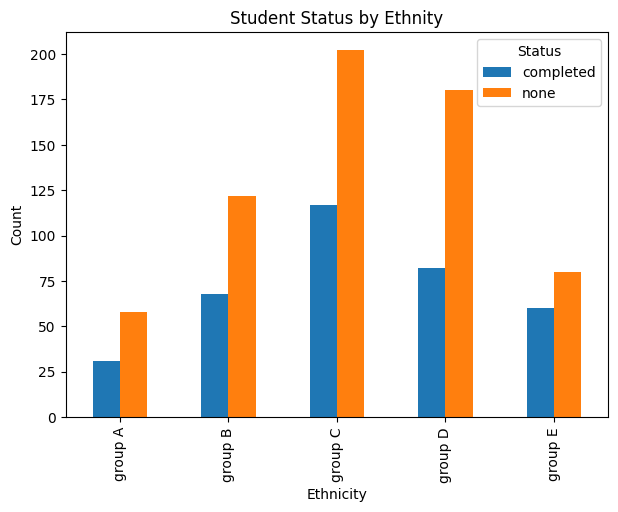

In [29]:
pd.crosstab(df['race_ethnicity'], df['test_preparation_course']).plot(
    kind='bar',
    # stacked=True,
    figsize=(7,5)
)

plt.title("Student Status by Ethnity")
plt.xlabel("Ethnicity")
plt.ylabel("Count")
plt.legend(title="Status")
plt.show()

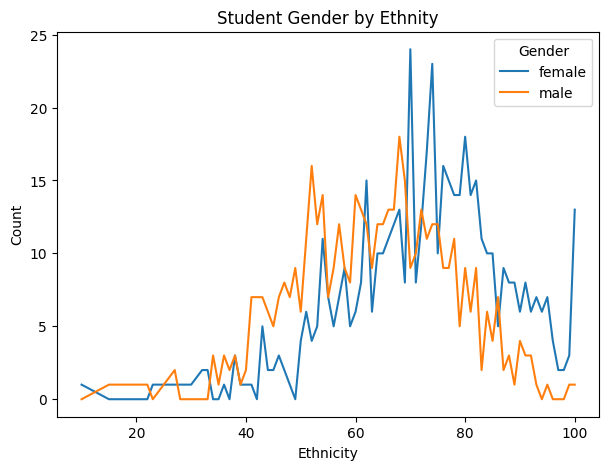

In [32]:
pd.crosstab(df['writing_score'], df['gender']).plot(
    kind='line',
    # stacked=True,
    figsize=(7,5)
)

plt.title("Student Gender by Ethnity")
plt.xlabel("Ethnicity")
plt.ylabel("Count")
plt.legend(title="Gender")
plt.show()

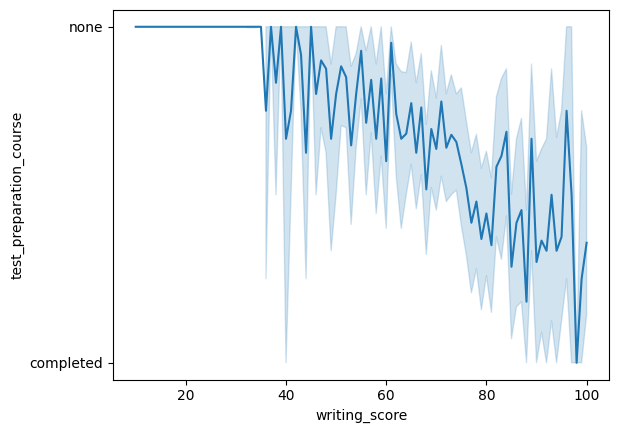

In [35]:
sns.lineplot(x="writing_score",y="test_preparation_course",data=df)
plt.show()